Tujuan secara umum: Untuk menguji apakah hubungan antara variabel dan faktor penentu sudah bisa terjawab melalui analisis panel regresi linear (langkah sebelumnya di `01_Analisis_Panel.ipynb`) atau harus menggunakan metode Random Forest. Ini untuk mengetahui apakah hubungan bisa dijawab karena linear, atau sebenarnya lebih kompleks (butuh algoritma Decision Tree-based seperti Random Forest).

Catatan: Di sini memerlukan import `01_model1_features.pkl` dan `01_model2_features.pkl` yang didapatkan dari notebook sebelumnya.

# Import dan Load

In [1]:
# Library olah data default
import pandas as pd
import numpy as np

# Export dan Import Fitur
import joblib

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [3]:
df_property = pd.read_excel('https://drive.google.com/uc?id=1jk8SfEEmw80GQCA-2TekI8zmX0tjPK4J', sheet_name='HASIL PERHITUNGAN')

In [4]:
der_features = joblib.load('01_model1_features.pkl')
tdr_features = joblib.load('01_model2_features.pkl')

In [5]:
X_cols = ['ROE', 'TAN', 'LIQ', 'GRW', 'TAX', 'AGE', 'NDTS']

# 01. Random Forest vs Regresi Data Panel

## Perbandingan R2 Secara Langsung

In [6]:
# ==========================================
# 1. PERSIAPAN DATA
# ==========================================
# Data Model 1 (FEM Style) -> Pakai Dummy Emiten
X_m1 = pd.get_dummies(df_property[X_cols + ['Emiten']], columns=['Emiten'], drop_first=True)
y_m1 = df_property['DER']

# Data Model 2 (REM Style) -> Tanpa Emiten (Global)
X_m2 = df_property[X_cols]
y_m2 = df_property['TDR']

In [7]:
# ==========================================
# 2. TRAINING MACHINE LEARNING (OOB SCORE)
# ==========================================
# Gunakan oob_score=True untuk mendapatkan R-Squared yang jujur
rf1_m1 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
rf1_m2 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

rf1_m1.fit(X_m1, y_m1)
rf1_m2.fit(X_m2, y_m2)

RandomForestRegressor(oob_score=True, random_state=42)

Nilai R2 yang digunakan adalah Random Forest OOB (Out-Of-Bag) Score, bukan R2 biasa. Karena menggunakan semua data tanpa split train dan test. Jika pakai R2 biasa, maka skor pasti >0.9 karena model sudah menghafal. Untuk itu OOB Score dinilai lebih masuk akal karena dinilai saat pelatihan model dengan data yang belum dilihat (tidak dipakai dalam bootstraping atau bagging). Agak mirip prinsipnya dengan K-Fold Cross Validation.

In [8]:
# ==========================================
# 3. OUTPUT PERBANDINGAN R-SQUARED
# ==========================================
print("=== KEKUATAN MENJELASKAN (EXPLANATORY POWER) ===")
print(f"Model 1 (Target DER) - RF OOB R-Squared : {rf1_m1.oob_score_:.4f}")
print(f"Model 2 (Target TDR) - RF OOB R-Squared : {rf1_m2.oob_score_:.4f}")

=== KEKUATAN MENJELASKAN (EXPLANATORY POWER) ===
Model 1 (Target DER) - RF OOB R-Squared : 0.7736
Model 2 (Target TDR) - RF OOB R-Squared : 0.7095


Berikut perbandingan dengan R2 yang didapatkan sebelumnya di model regresi linear panel
|  | Model 1 (DER) | Model 2 (TDR) |
| -- | -- | -- |
| Regresi Panel   | 0.2666   | 0.2803 |
| Random Forest   | 0.7736   | 0.7095 |

Hal ini berarti:
1. Hubungan yang terjadi antara variabel X dengan Y adalah **non-linear**. Yang mana ini bisa diketahui di Random Forest, tapi tidak bisa diketahui di Regresi Linear.
2. Random Forest berhasil menangkap bagaimana variabel saling mempengaruhi secara gabungan. Sementara regresi panel hanya melihat secara individu tanpa gabungan.
3. Angka R2 0.7 di Random Forest berarti sebenarnya data panel memiliki pola yang sangat kuat. Teori linear yang hanya 0.2 hanya mampu menjelaskan sebagian kecil dari fenomena nyata di industri properti.

## Feature Importance

In [9]:
# Cek Variabel Paling Berpengaruh di Model 1 (DER)
importances_rf1_m1 = pd.DataFrame({
    'Variabel': X_m1.columns,
    'Kekuatan (RF)': rf1_m1.feature_importances_
}).sort_values(by='Kekuatan (RF)', ascending=False)

print("\n=== URUTAN KEKUATAN VARIABEL MODEL 1 (MACHINE LEARNING) ===")
importances_rf1_m1.head(12)


=== URUTAN KEKUATAN VARIABEL MODEL 1 (MACHINE LEARNING) ===


,Variabel,Kekuatan (RF)
37,Emiten_PPRO,0.427646
0,ROE,0.119235
2,LIQ,0.107984
30,Emiten_MDLN,0.084925
1,TAN,0.077614
5,AGE,0.031360
6,NDTS,0.027224
3,GRW,0.020628
4,TAX,0.019743
7,Emiten_ASRI,0.011703


In [10]:
# Cek Variabel Paling Berpengaruh di Model 2 (TDR)
importances_rf1_m2 = pd.DataFrame({
    'Variabel': X_m2.columns,
    'Kekuatan (RF)': rf1_m2.feature_importances_
}).sort_values(by='Kekuatan (RF)', ascending=False)

print("\n=== URUTAN KEKUATAN VARIABEL MODEL 2 (MACHINE LEARNING) ===")
importances_rf1_m2


=== URUTAN KEKUATAN VARIABEL MODEL 2 (MACHINE LEARNING) ===


,Variabel,Kekuatan (RF)
2,LIQ,0.279045
1,TAN,0.278783
0,ROE,0.159819
6,NDTS,0.131253
5,AGE,0.054888
3,GRW,0.050443
4,TAX,0.045768


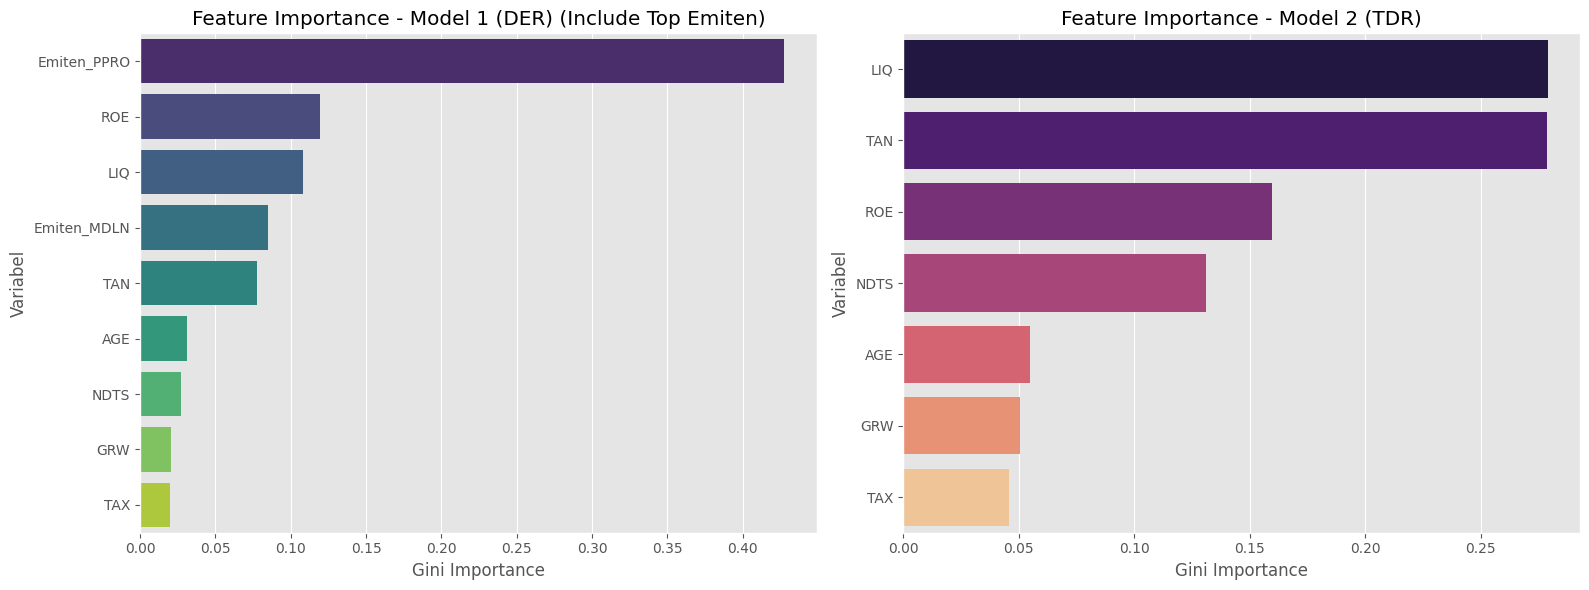

In [11]:
# Visualization of Feature Importance for both Random Forest models

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model 1 (DER) - Top 9
sns.barplot(x='Kekuatan (RF)', y='Variabel', data=importances_rf1_m1.head(9), ax=axes[0], palette='viridis', hue='Variabel', legend=False)
axes[0].set_title('Feature Importance - Model 1 (DER) (Include Top Emiten)')
axes[0].set_xlabel('Gini Importance')

# Plot Model 2 (TDR)
sns.barplot(x='Kekuatan (RF)', y='Variabel', data=importances_rf1_m2, ax=axes[1], palette='magma', hue='Variabel', legend=False)
axes[1].set_title('Feature Importance - Model 2 (TDR)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

Berikut perbandingan importance variable dari sebelumnya (Regresi Panel):
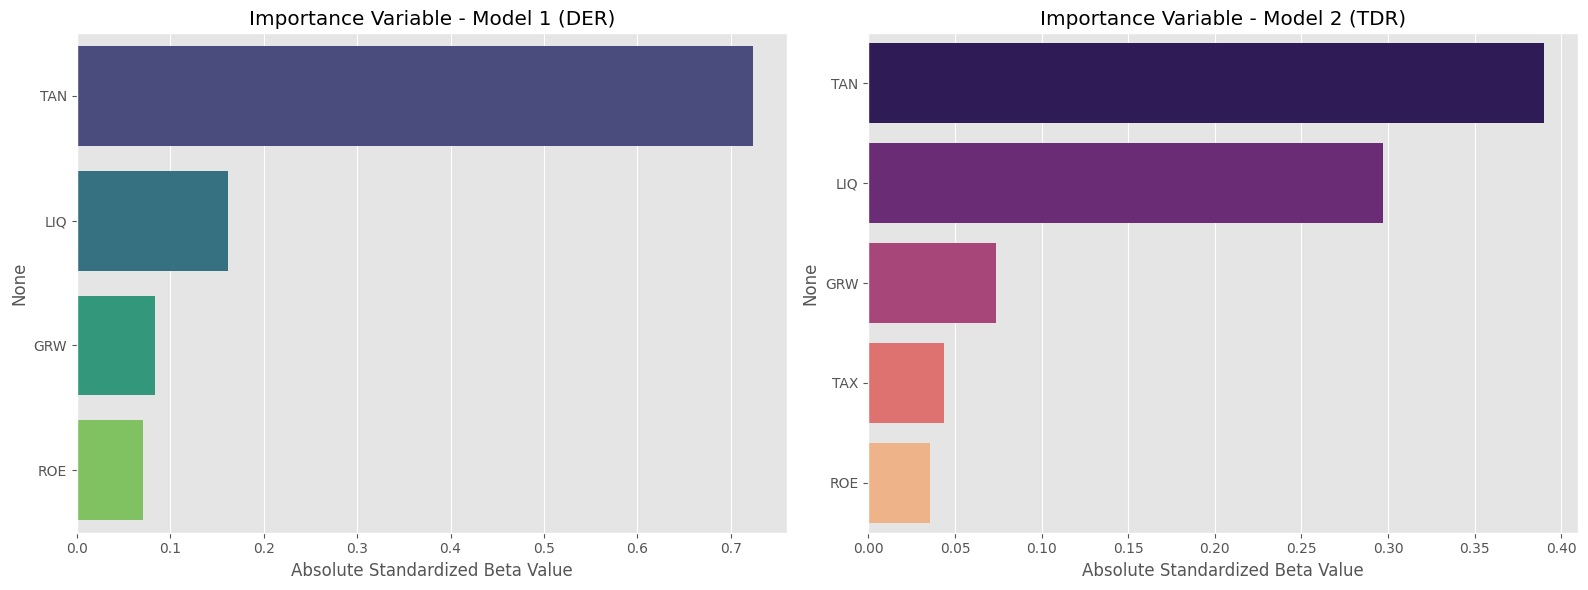

Hasil Random Forest memberikan sudut pandang yang lebih realistis dibandingkan ekonometrika klasik.

**1. Model 1 (Target DER): "DNA" Perusahaan Lebih Kuat dari Angka**

Munculnya `Emiten_PPRO` (0.427) sebagai juara mutlak, bahkan jauh mengalahkan semua rasio keuangan, mengonfirmasi fenomena *Unobserved Heterogeneity*.
* **Makna Bisnis:** Rasio Utang terhadap Modal (DER) sangat didikte oleh tradisi, keberanian manajemen, atau masalah bawaan spesifik dari perusahaan tertentu. PPRO (PP Properti) dan MDLN (Modernland) memiliki profil utang yang sangat ekstrem atau khas, sehingga mesin menganggap "mengetahui nama perusahaannya" jauh lebih penting daripada melihat seberapa besar laba (ROE) atau kas (LIQ) mereka di tahun tersebut.
* **Pergeseran Fundamental:** Di antara rasio keuangan, mesin menemukan bahwa **ROE (Laba)** dan **LIQ (Kas)** adalah penggerak non-linear terkuat untuk DER, menggeser TAN (Aset Fisik) yang sebelumnya merajai di regresi linear. Ini berarti lonjakan laba atau krisis kas secara instan mengubah keputusan utang (DER) di dunia nyata.

**2. Model 2 (Target TDR): Uang Tunai Adalah Raja (Cash is King)**

Ketika membuang identitas emiten dan melihat total utang terhadap aset secara global, urutannya menjadi: **LIQ > TAN > ROE > NDTS > AGE > GRW > TAX**.
* **Makna Bisnis:** Untuk menebak seberapa besar tumpukan total utang (TDR) sebuah perusahaan properti secara umum, indikator yang paling bisa diandalkan adalah **Likuiditas (LIQ)**. Jika kas mereka berdarah, utang pasti membengkak. Jika kas aman, utang terkendali. Jaminan aset fisik (TAN) menyusul di posisi kedua sebagai syarat pencairan utang tersebut. LIQ dan TAN masih konsisten berada di 2 peringkat teratas.

**3. Kejatuhan Teori "Tameng Pajak" (TAX)**
Ini adalah temuan paling memuaskan dari perbandingan Regresi vs Machine Learning. Pada regresi linear (REM), TAX dianggap signifikan dan cukup kuat. Namun di mata Machine Learning (Model 2), **TAX berada di posisi paling bawah**.
* **Mengapa ini terjadi?** Regresi linear menemukan bahwa *secara rata-rata statistik*, ada hubungan lurus antara pajak dan utang (bukti teori *Tax Shield*). Namun, *Machine Learning* melihat bahwa dalam praktiknya, **Pajak sama sekali tidak berguna untuk memprediksi nominal utang**.
* Perusahaan properti mungkin berniat memanfaatkan utang untuk menghindari pajak, tetapi pada realitas operasionalnya, keputusan menambah utang murni didorong oleh ketersediaan kas (LIQ) dan jaminan (TAN).

**Kesimpulan Eksplorasi:**

Regresi Linear (FEM/REM) sangat bagus untuk membuktikan **"apakah teori keuangan itu ada?"** (misalnya: membuktikan niat perusahaan menggunakan tameng pajak).

Namun, Machine Learning (Random Forest) mengungkap **"apa yang sebenarnya terjadi di lapangan?"** (bahwa nama perusahaan seperti PPRO dan jumlah uang kas harian jauh lebih mendikte keputusan utang di dunia nyata, sementara urusan pajak hanyalah pertimbangan di atas kertas).

## Menghitung RMSE dan MAE (Untuk Perbandingan ke depan)

RMSE (Root Mean Square Error) dan MAE (Mean Absolute Error) adalah metrik untuk mengetahui apakah model regresi sudah baik atau belum selain R2. Semakin mendekati 0, maka semakin baik.

In [12]:
# Evaluasi Model 1 (Full Features)
y_pred_m1 = rf1_m1.predict(X_m1)
rmse_rf1_m1 = np.sqrt(mean_squared_error(y_m1, y_pred_m1))
mae_rf1_m1 = mean_absolute_error(y_m1, y_pred_m1)

# Evaluasi Model 2 (Full Features)
y_pred_m2 = rf1_m2.predict(X_m2)
rmse_rf1_m2 = np.sqrt(mean_squared_error(y_m2, y_pred_m2))
mae_rf1_m2 = mean_absolute_error(y_m2, y_pred_m2)

print("=== METRIK EVALUASI (FULL FEATURES) ===")
print(f"Model 1 (DER) - RMSE: {rmse_rf1_m1:.4f}, MAE: {mae_rf1_m1:.4f}")
print(f"Model 2 (TDR) - RMSE: {rmse_rf1_m2:.4f}, MAE: {mae_rf1_m2:.4f}")

=== METRIK EVALUASI (FULL FEATURES) ===
Model 1 (DER) - RMSE: 0.1614, MAE: 0.0884
Model 2 (TDR) - RMSE: 0.0389, MAE: 0.0303


# 02. Random Forest Semua Variabel X

Sebelumnya di analisis panel, variabel `SIZ` dibuang karena tidak lolos Uji Multikolinearitas. Namun untuk Random Forest, lebih robust dan tidak memerlukan uji ini. Jadi tujuan di sini adalah membandingkan performa Random Forest dengan atau tanpa SIZ.

In [13]:
X_cols_all = X_cols.copy()
X_cols_all.append('SIZ')
X_cols_all

['ROE', 'TAN', 'LIQ', 'GRW', 'TAX', 'AGE', 'NDTS', 'SIZ']

## Perbandingan OOB R2, RMSE, dan MAE dengan Sebelumnya

In [14]:
# ==========================================
# 1. PERSIAPAN DATA (DENGAN SIZ)
# ==========================================
X_rf2_m1 = pd.get_dummies(df_property[X_cols_all + ['Emiten']], columns=['Emiten'], drop_first=True)
y_rf2_m1 = df_property['DER']

X_rf2_m2 = df_property[X_cols_all]
y_rf2_m2 = df_property['TDR']

In [15]:
# ==========================================
# 2. TRAINING MODEL DENGAN SIZ
# ==========================================
rf2_m1 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
rf2_m2 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

rf2_m1.fit(X_rf2_m1, y_rf2_m1)
rf2_m2.fit(X_rf2_m2, y_rf2_m2)

RandomForestRegressor(oob_score=True, random_state=42)

In [16]:
# ==========================================
# 3. EVALUASI DAN PERBANDINGAN METRIK
# ==========================================
# Prediksi untuk hitung RMSE/MAE
y_pred_rf2_m1 = rf2_m1.predict(X_rf2_m1)
y_pred_rf2_m2 = rf2_m2.predict(X_rf2_m2)

rmse_rf2_m1 = np.sqrt(mean_squared_error(y_rf2_m1, y_pred_rf2_m1))
mae_rf2_m1 = mean_absolute_error(y_rf2_m1, y_pred_rf2_m1)

rmse_rf2_m2 = np.sqrt(mean_squared_error(y_rf2_m2, y_pred_rf2_m2))
mae_rf2_m2 = mean_absolute_error(y_rf2_m2, y_pred_rf2_m2)

# Tampilkan Tabel Perbandingan
comparison_data = {
    'Model': ['Model 1 (DER) Tanpa SIZ', 'Model 1 (DER) Dengan SIZ', 'Model 2 (TDR) Tanpa SIZ', 'Model 2 (TDR) Dengan SIZ'],
    'OOB R2': [rf1_m1.oob_score_, rf2_m1.oob_score_, rf1_m2.oob_score_, rf2_m2.oob_score_],
    'RMSE': [rmse_rf1_m1, rmse_rf2_m1, rmse_rf1_m2, rmse_rf2_m2],
    'MAE': [mae_rf1_m1, mae_rf2_m1, mae_rf1_m2, mae_rf2_m2]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison.round(4)

,Model,OOB R2,RMSE,MAE
0,Model 1 (DER) Tanpa SIZ,0.7736,0.1614,0.0884
1,Model 1 (DER) Dengan SIZ,0.7944,0.1529,0.0787
2,Model 2 (TDR) Tanpa SIZ,0.7095,0.0389,0.0303
3,Model 2 (TDR) Dengan SIZ,0.7732,0.0351,0.0261


Model dengan SIZ justru punya performa yang lebih baik. Ini berarti Random Forest menangkap pola dari variabel yang dianggap buruk karena Multikolinearitas. Namun di Random Forest karena tidak mementingkan Multikolinearitas, maka SIZ bisa jadi pertimbangan dalam memepngaruhi baik DER maupun TDR.

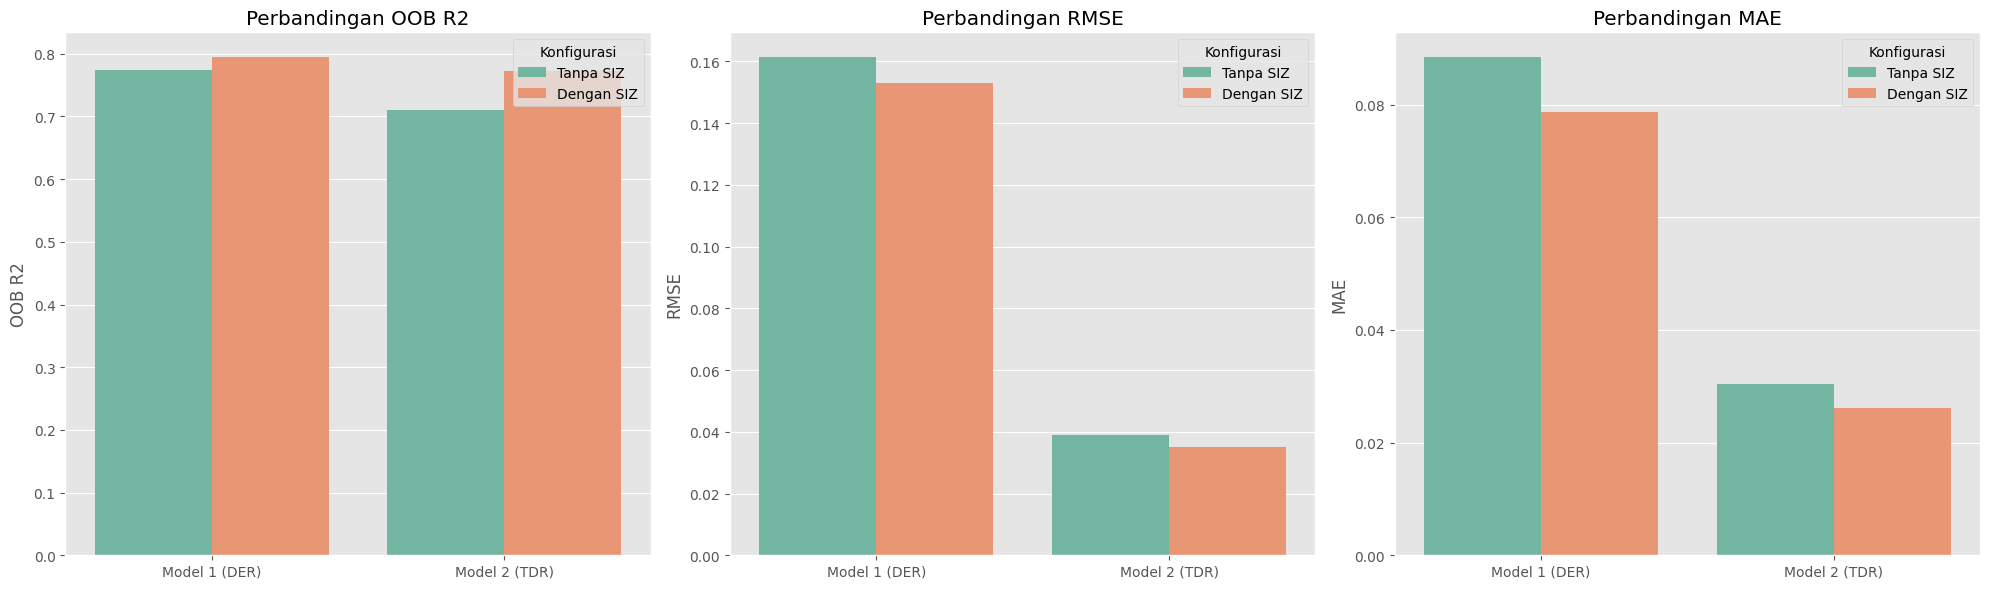

In [17]:
# ==========================================
# 4. VISUALISASI PERBANDINGAN PERFORMA
# ==========================================

# Prepare data for plotting
plot_df = df_comparison.copy()
# Add grouping columns for plotting
plot_df['Target'] = ['Model 1 (DER)', 'Model 1 (DER)', 'Model 2 (TDR)', 'Model 2 (TDR)']
plot_df['Config'] = ['Tanpa SIZ', 'Dengan SIZ', 'Tanpa SIZ', 'Dengan SIZ']

metrics = ['OOB R2', 'RMSE', 'MAE']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics):
    sns.barplot(x='Target', y=metric, hue='Config', data=plot_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Perbandingan {metric}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].legend(title='Konfigurasi')

plt.tight_layout()
plt.show()

R2 = Semakin tinggi atau mendekati 1 maka semakin baik. RMSE dan MAE semakin rendah atau mendekati 0 maka semakin baik.

## Feature Importance (Dengan SIZ)

In [18]:
# Cek Variabel Paling Berpengaruh di Model 1 (DER) - Dengan SIZ
importances_rf2_m1 = pd.DataFrame({
    'Variabel': X_rf2_m1.columns,
    'Kekuatan (RF)': rf2_m1.feature_importances_
}).sort_values(by='Kekuatan (RF)', ascending=False)

# Cek Variabel Paling Berpengaruh di Model 2 (TDR) - Dengan SIZ
importances_rf2_m2 = pd.DataFrame({
    'Variabel': X_rf2_m2.columns,
    'Kekuatan (RF)': rf2_m2.feature_importances_
}).sort_values(by='Kekuatan (RF)', ascending=False)

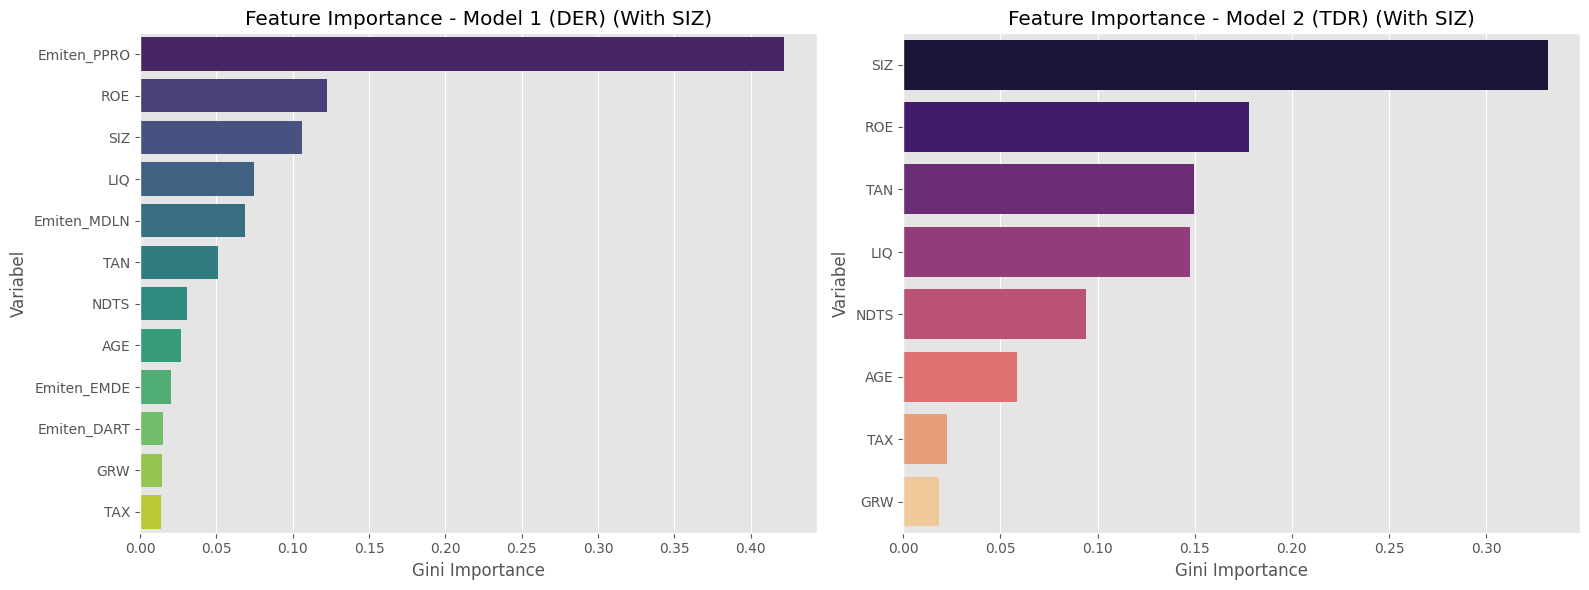

In [19]:
# Visualization of Feature Importance for RF models with SIZ

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model 1 (DER) - Top 10 with SIZ
sns.barplot(x='Kekuatan (RF)', y='Variabel', data=importances_rf2_m1.head(12), ax=axes[0], palette='viridis', hue='Variabel', legend=False)
axes[0].set_title('Feature Importance - Model 1 (DER) (With SIZ)')
axes[0].set_xlabel('Gini Importance')

# Plot Model 2 (TDR) - With SIZ
sns.barplot(x='Kekuatan (RF)', y='Variabel', data=importances_rf2_m2, ax=axes[1], palette='magma', hue='Variabel', legend=False)
axes[1].set_title('Feature Importance - Model 2 (TDR) (With SIZ)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

Di Random Forest, SIZ justru menjadi salah satu variabel atau fitur yang berpengaruh. Pada Model 1, SIZ berada di urutan 3, sedangkan pada Model 2, SIZ langsung berada di peringkat pertama, mengalahkan seluruh variabel yang lain.

# 03. Random Forest Variabel Signifikan

Gunakan `der_features` untuk Model 1 dan `tdr_features` untuk Model 2.

In [20]:
# Model 3 (Target DER) - Menggunakan der_features + Emiten Dummies
X_rf3_m1 = pd.get_dummies(df_property[der_features + ['Emiten']], columns=['Emiten'], drop_first=True)
y_rf3_m1 = df_property['DER']

# Model 3 (Target TDR) - Menggunakan tdr_features
X_rf3_m2 = df_property[tdr_features]
y_rf3_m2 = df_property['TDR']

## Perbandingan Ketiga Random Forest

In [21]:
# Training Model
rf3_m1 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
rf3_m2 = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)

rf3_m1.fit(X_rf3_m1, y_rf3_m1)
rf3_m2.fit(X_rf3_m2, y_rf3_m2)

RandomForestRegressor(oob_score=True, random_state=42)

In [22]:
# Evaluasi Metrik
y_pred_rf3_m1 = rf3_m1.predict(X_rf3_m1)
y_pred_rf3_m2 = rf3_m2.predict(X_rf3_m2)

rmse_rf3_m1 = np.sqrt(mean_squared_error(y_rf3_m1, y_pred_rf3_m1))
mae_rf3_m1 = mean_absolute_error(y_rf3_m1, y_pred_rf3_m1)

rmse_rf3_m2 = np.sqrt(mean_squared_error(y_rf3_m2, y_pred_rf3_m2))
mae_rf3_m2 = mean_absolute_error(y_rf3_m2, y_pred_rf3_m2)

print(f"Model 1 (DER - Selected) - OOB R2: {rf3_m1.oob_score_:.4f}, RMSE: {rmse_rf3_m1:.4f}, MAE: {mae_rf3_m1:.4f}")
print(f"Model 2 (TDR - Selected) - OOB R2: {rf3_m2.oob_score_:.4f}, RMSE: {rmse_rf3_m2:.4f}, MAE: {mae_rf3_m2:.4f}")

Model 1 (DER - Selected) - OOB R2: 0.7895, RMSE: 0.1556, MAE: 0.0820
Model 2 (TDR - Selected) - OOB R2: 0.6459, RMSE: 0.0424, MAE: 0.0340


In [23]:
# Menyiapkan data baru untuk model signifikan
new_rows = pd.DataFrame({
    'Model': ['Model 1 (DER) Signifikan', 'Model 2 (TDR) Signifikan'],
    'OOB R2': [rf3_m1.oob_score_, rf3_m2.oob_score_],
    'RMSE': [rmse_rf3_m1, rmse_rf3_m2],
    'MAE': [mae_rf3_m1, mae_rf3_m2]
})

# Membagi dataframe lama untuk menyisipkan baris di index tertentu
df_comp_part1 = df_comparison.iloc[:2]
df_comp_part2 = df_comparison.iloc[2:]

# Gabungkan: Part 1 + Row 0 Signifikan + Part 2 + Row 1 Signifikan
df_comparison_updated = pd.concat([
    df_comp_part1,
    new_rows.iloc[[0]],
    df_comp_part2,
    new_rows.iloc[[1]]
]).reset_index(drop=True)

df_comparison = df_comparison_updated
df_comparison.round(4)

,Model,OOB R2,RMSE,MAE
0,Model 1 (DER) Tanpa SIZ,0.7736,0.1614,0.0884
1,Model 1 (DER) Dengan SIZ,0.7944,0.1529,0.0787
2,Model 1 (DER) Signifikan,0.7895,0.1556,0.0820
3,Model 2 (TDR) Tanpa SIZ,0.7095,0.0389,0.0303
4,Model 2 (TDR) Dengan SIZ,0.7732,0.0351,0.0261
5,Model 2 (TDR) Signifikan,0.6459,0.0424,0.0340


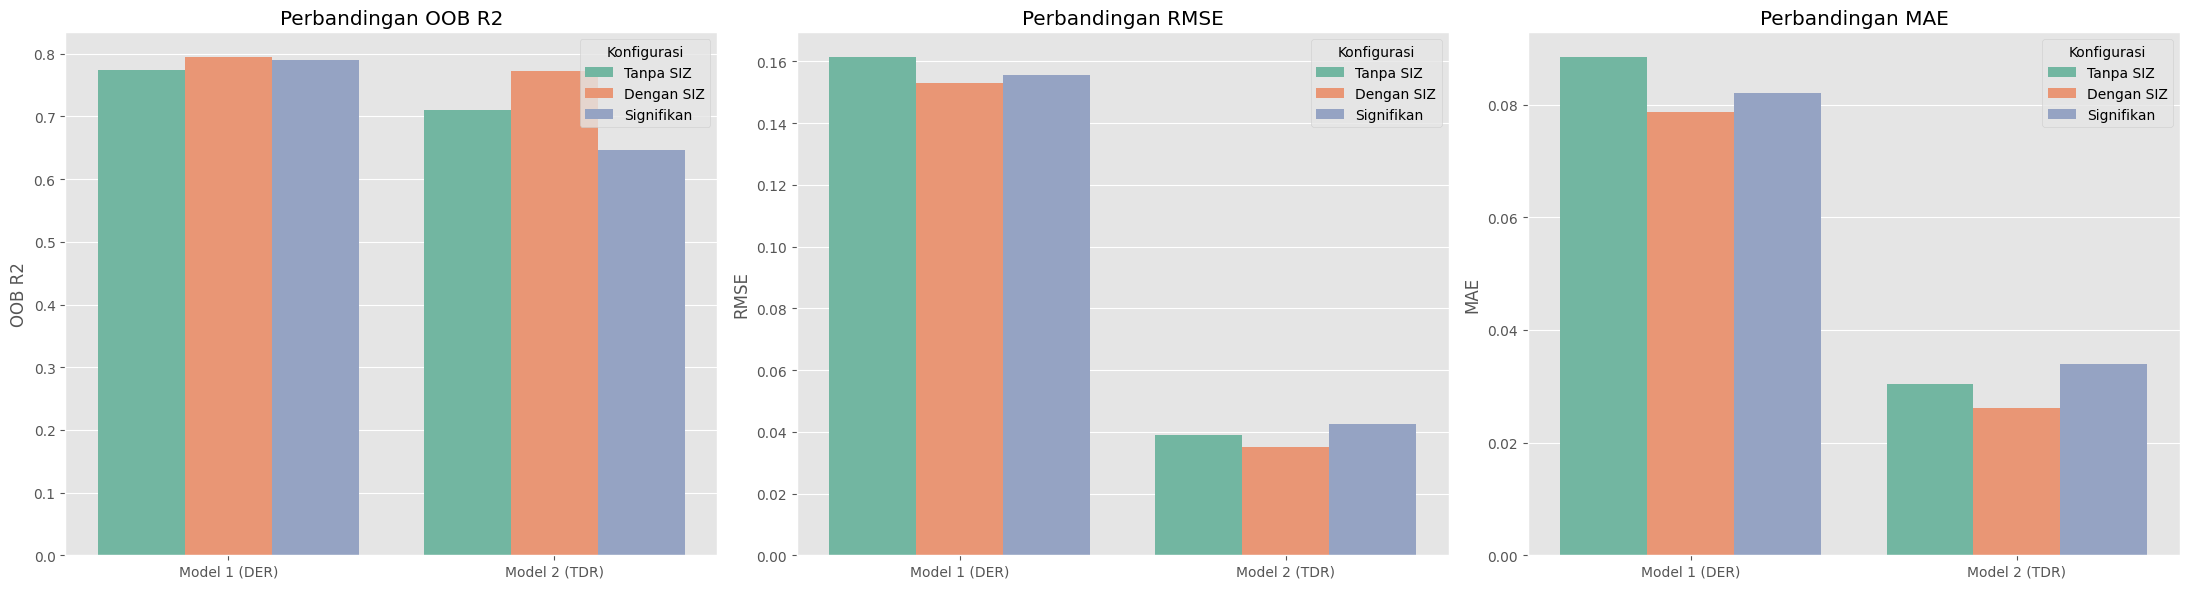

In [24]:
# ==========================================
# 4. VISUALISASI PERBANDINGAN PERFORMA (UPDATED)
# ==========================================

# Prepare data for plotting
plot_df = df_comparison.copy()

# Map the Target and Config based on the Model names in df_comparison
plot_df['Target'] = plot_df['Model'].apply(lambda x: 'Model 1 (DER)' if 'Model 1' in x else 'Model 2 (TDR)')
plot_df['Config'] = plot_df['Model'].apply(lambda x: 'Tanpa SIZ' if 'Tanpa SIZ' in x else ('Dengan SIZ' if 'Dengan SIZ' in x else 'Signifikan'))

metrics = ['OOB R2', 'RMSE', 'MAE']
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, metric in enumerate(metrics):
    sns.barplot(x='Target', y=metric, hue='Config', data=plot_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Perbandingan {metric}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].legend(title='Konfigurasi', loc='best')

plt.tight_layout()
plt.show()

* Untuk kedua Model DER dan TDR, dengan memasukan variabel SIZ atau dengan kata lain memasukan seluruh variabel, itu justru menjadi Model Random Forest terbaik.
* Pada Model 2 (TDR), memasukan hanya variabel Signifikan justru lebih buruk daripada memasukan semua variabel kecuali SIZ. Ini berarti beberapa variabel yang tidak signifikan justru lebih memiliki kemampuan prediksi yang lebih baik.
* Pada Model 1 (DER), model dengan variabel Signifikan justru lebih baik daripada dengan semua variabel kecuali SIZ. Hal ini berarti, variabel tidak signifikan seperti TAX, AGE, NDTS memang merupakan variabel sampah atau pengganggu (noise). Tapi perlu diingat bahwa memasukan seluruh variabel masih lebih baik daripada memasukan variabel signifikan saja karena pengaruh SIZ yang cukup besar.

## Feature Importance Signifikan

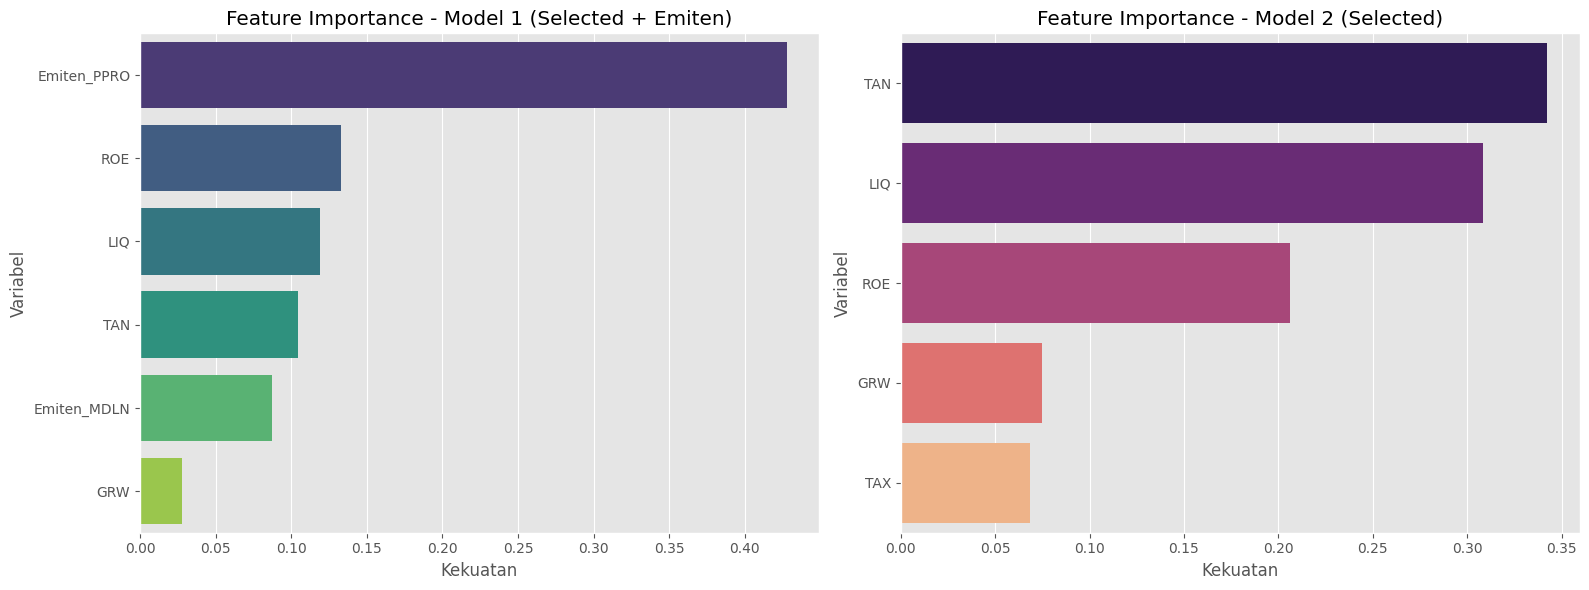

In [25]:
# Feature Importance for Selected Features
importances_rf3_m1 = pd.DataFrame({'Variabel': X_rf3_m1.columns, 'Kekuatan': rf3_m1.feature_importances_}).sort_values(by='Kekuatan', ascending=False)
importances_rf3_m2 = pd.DataFrame({'Variabel': X_rf3_m2.columns, 'Kekuatan': rf3_m2.feature_importances_}).sort_values(by='Kekuatan', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Kekuatan', y='Variabel', data=importances_rf3_m1.head(6), ax=axes[0], palette='viridis', hue='Variabel', legend=False)
axes[0].set_title('Feature Importance - Model 1 (Selected + Emiten)')

sns.barplot(x='Kekuatan', y='Variabel', data=importances_rf3_m2, ax=axes[1], palette='magma', hue='Variabel', legend=False)
axes[1].set_title('Feature Importance - Model 2 (Selected)')

plt.tight_layout()
plt.show()

# Export dan Kesimpulan

Untuk selanjutnya, Random Forest akan menggunakan semua variabel karena itu merupakan model dengan performa terbaik. Lebih lanjut juga untuk prediksi DER, akan di-export beberapa variabel Emiten yang memiliki nilai importance dari variabel X.

In [26]:
emiten_names = [col.split('Emiten_')[1] for col in importances_rf2_m1.head(12)['Variabel'] if 'Emiten_' in col]
print(emiten_names)

['PPRO', 'MDLN', 'EMDE', 'DART']


In [27]:
joblib.dump(emiten_names, '02_model1_features_emiten.pkl')

['02_model1_features_emiten.pkl']

Executive Summary:

Ukuran Perusahaan (SIZ) adalah nyawa utama dari struktur utang industri properti yang selama ini 'disembunyikan' oleh keterbatasan uji asumsi statistik klasik. Ketika dianalisis menggunakan Machine Learning, terbukti bahwa skala aset (SIZ) dan profitabilitas (ROE) adalah penggerak sejati dari total utang (TDR), menepis teori bahwa perusahaan agresif berutang hanya demi menghindari pajak (TAX). Di sisi lain, proporsi utang terhadap ekuitas (DER) terbukti tidak sepenuhnya rasional secara matematis, melainkan sangat bergantung pada kultur, keberanian manajemen, dan rekam jejak spesifik dari masing-masing entitas perusahaan (DNA Emiten)